In [5]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)


In [7]:
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)



error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


In [6]:
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [7]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

# Step#2: Load moon image
img = data.moon()


/Users/student/.pyenv/versions/ai/lib/python3.12/site-packages/skimage/color/colorconv.py:55: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy import linalg


In [8]:
# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))


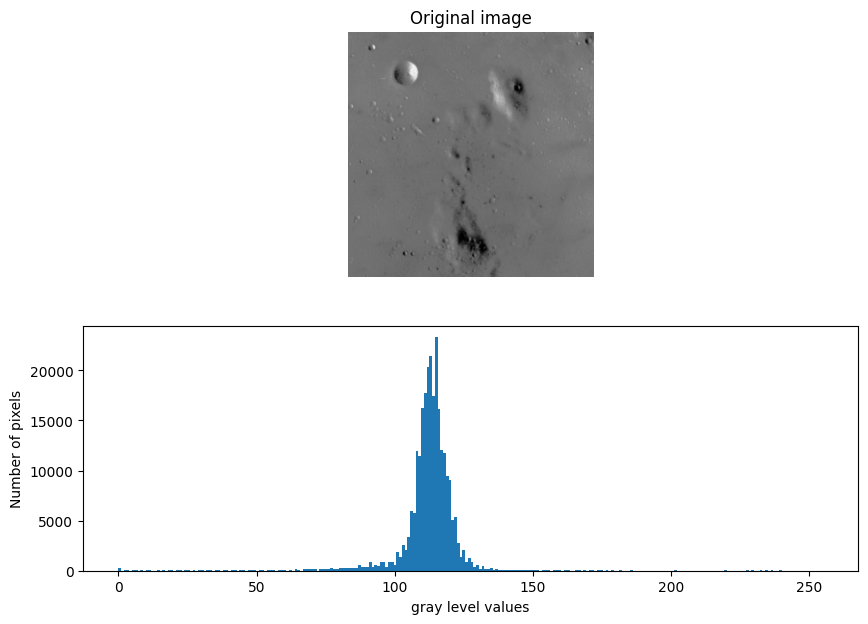

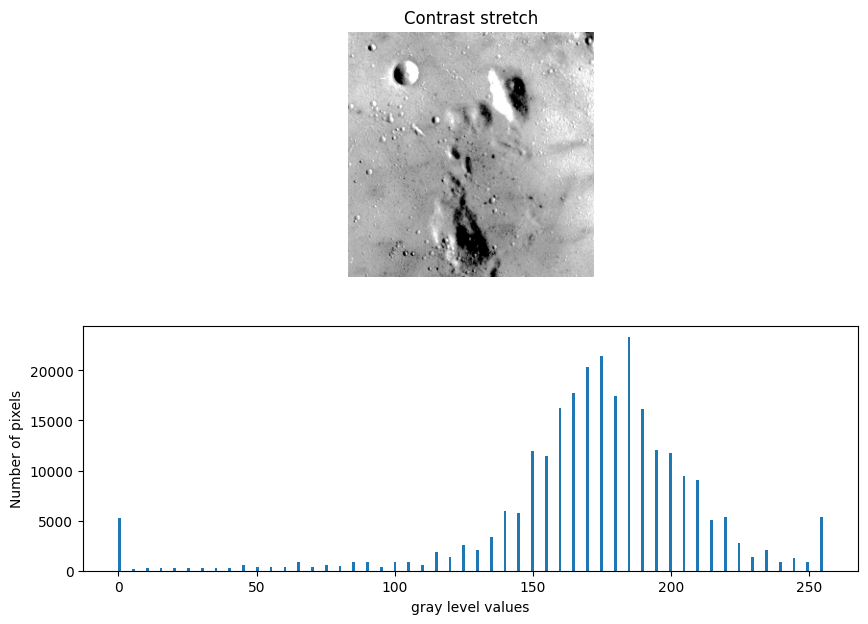

In [9]:
# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 

In [ ]:
# Task#1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram
p2, p98 = np.percentile(img, (3, 80))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(img_rescale, cmap='gray')
plt.title("Rescaled (3%-80%)")

plt.show()

# Histogram
plt.hist(img_rescale.flat, bins=256, range=(0,255))
plt.title("Histogram after rescale")
plt.show()

# Task#2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.
img_eq = exposure.equalize_hist(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_eq, cmap='gray')
plt.title("Equalized Image")

plt.subplot(1,2,2)
plt.hist(img_eq.flat, bins=256)
plt.title("Histogram Equalized")

plt.show()
# Task#3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching
from skimage import data

image = data.chelsea()
reference = data.rocket()

matched = exposure.match_histograms(image, reference, channel_axis=-1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original (chelsea)")

plt.subplot(1,3,2)
plt.imshow(reference)
plt.title("Reference (rocket)")

plt.subplot(1,3,3)
plt.imshow(matched)
plt.title("Matched")

plt.show()